# Sistema Fuzzy Mamdani + PSO — Avaliação de Risco de Crédito

**Disciplina:** Inteligência Artificial e Computacional (0700M8) — CESUPA 01/2026
**AV2 Parte 1:** Sistema de Controle Fuzzy (Opção B — Produto)
**AV2 Parte 2:** Computação Bioinspirada — PSO (Alternativa 2: Integração Fuzzy-Evolutiva)

---

Sistema de apoio à decisão para **avaliação de risco de crédito** usando inferência fuzzy
Mamdani. Os parâmetros das funções de pertinência são otimizados pelo **PSO**,
que usa o próprio sistema fuzzy como função de aptidão.

| Variável | Descrição | Universo |
|----------|-----------|---------|
| `renda` | Renda mensal bruta (R$) | [0, 20 000] |
| `comprometimento` | % da renda comprometida com dívidas | [0, 100] |
| `score` | Pontuação de crédito | [0, 1 000] |
| `tempo_emprego` | Tempo no emprego atual (anos) | [0, 30] |
| **`risco`** | Risco de crédito (saída) | [0, 100] |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import time
import json
import os

np.random.seed(42)
os.makedirs("resultados/fuzzy_antes", exist_ok=True)
os.makedirs("resultados/fuzzy_depois",  exist_ok=True)
os.makedirs("resultados/evolucao",    exist_ok=True)

U_RISCO     = np.linspace(0, 100, 501)
SEED_GLOBAL = 42
print("Importacoes concluidas.")


Importacoes concluidas.


## 2. Parâmetros Padrão

Cada função de pertinência triangular é definida por `[a, b, c]`:
`a` = início, `b` = pico (pertinência 1,0), `c` = fim.


In [2]:
DEFAULT_PARAMS = {
    # renda em R$  [0, 20000]
    "renda_muito_baixa": [    0,     0,  4000],
    "renda_baixa":       [ 1000,  5000,  9000],
    "renda_media":       [ 5000, 10000, 15000],
    "renda_alta":        [10000, 15000, 19000],
    "renda_muito_alta":  [15000, 20000, 20000],
    # comprometimento %  [0, 100]
    "comp_baixo":        [   0,    0,   25],
    "comp_moderado":     [  10,   30,   50],
    "comp_alto":         [  40,   60,   80],
    "comp_muito_alto":   [  65,  100,  100],
    # score [0, 1000]
    "score_muito_ruim":  [   0,    0,  200],
    "score_ruim":        [ 100,  250,  400],
    "score_regular":     [ 300,  500,  700],
    "score_bom":         [ 550,  700,  850],
    "score_muito_bom":   [ 750, 1000, 1000],
    # tempo_emprego em anos  [0, 30]
    "tempo_curto":       [  0,   0,   5],
    "tempo_moderado":    [  2,   7,  14],
    "tempo_longo":       [  9,  16,  23],
    "tempo_muito_longo": [ 18,  30,  30],
    # risco (saida)  [0, 100]
    "risco_muito_baixo": [  0,   0,  20],
    "risco_baixo":       [ 10,  25,  40],
    "risco_medio":       [ 30,  50,  70],
    "risco_alto":        [ 60,  75,  90],
    "risco_muito_alto":  [ 80, 100, 100],
}

LIMITES_VARS = {
    "renda": (0, 20000), "comp": (0, 100), "score": (0, 1000),
    "tempo": (0, 30),    "risco": (0, 100),
}

def prefixo(key):
    for v in ["renda","comp","score","tempo","risco"]:
        if key.startswith(v):
            return v

KEYS_OPT = list(DEFAULT_PARAMS.keys())
DIM      = len(KEYS_OPT) * 3
print(f"Parametros carregados: {len(DEFAULT_PARAMS)} grupos, {DIM} dimensoes para o PSO")


Parametros carregados: 23 grupos, 69 dimensoes para o PSO


## 3. Inferência Mamdani — Implementação Rápida (NumPy)

Para a **visualização** usamos scikit-fuzzy (Seção 4).
Para a **otimização PSO** usamos implementação direta em NumPy (~0,06 ms/avaliação).

**18 Regras Fuzzy:**

| # | SE… | ENTÃO `risco` |
|---|-----|---------------|
| 1 | score Muito Bom ∧ comp Baixo | Muito Baixo |
| 2 | score Muito Bom ∧ comp Moderado | Baixo |
| 3 | score Muito Bom ∧ comp Alto | Médio |
| 4 | score Bom ∧ comp Baixo | Muito Baixo |
| 5 | score Bom ∧ comp Moderado | Baixo |
| 6 | score Bom ∧ comp Alto | Médio |
| 7 | score Regular ∧ comp Baixo | Baixo |
| 8 | score Regular ∧ comp Moderado | Médio |
| 9 | score Regular ∧ comp Alto | Alto |
| 10 | score Ruim ∧ comp Baixo | Médio |
| 11 | score Ruim ∧ comp Moderado | Alto |
| 12 | score Ruim ∧ comp Alto | Muito Alto |
| 13 | score Muito Ruim | Muito Alto |
| 14 | renda Muito Alta ∧ score Bom ∧ comp Baixo | Muito Baixo |
| 15 | renda Muito Baixa ∧ comp Muito Alto | Muito Alto |
| 16 | score Regular ∧ tempo Muito Longo ∧ comp Baixo | Baixo |
| 17 | score Bom ∧ tempo Muito Longo | Muito Baixo |
| 18 | score Regular ∧ tempo Curto ∧ renda Baixa | Alto |


In [3]:
def trimf_val(x, a, b, c):
    if x == b:               return 1.0
    if a < b and a < x < b:  return (x - a) / (b - a)
    if b < c and b < x < c:  return (c - x) / (c - b)
    return 0.0

def trimf_arr(u, abc):
    return fuzz.trimf(u, abc)

def mamdani_fast(renda_v, comp_v, score_v, tempo_v, params):
    mr = {k: trimf_val(renda_v, *params[f"renda_{k}"]) for k in ["muito_baixa","baixa","media","alta","muito_alta"]}
    mc = {k: trimf_val(comp_v,  *params[f"comp_{k}"])  for k in ["baixo","moderado","alto","muito_alto"]}
    ms = {k: trimf_val(score_v, *params[f"score_{k}"]) for k in ["muito_ruim","ruim","regular","bom","muito_bom"]}
    mt = {k: trimf_val(tempo_v, *params[f"tempo_{k}"]) for k in ["curto","moderado","longo","muito_longo"]}

    regras = [
        (min(ms["muito_bom"],  mc["baixo"]),                       "muito_baixo"),
        (min(ms["muito_bom"],  mc["moderado"]),                    "baixo"),
        (min(ms["muito_bom"],  mc["alto"]),                        "medio"),
        (min(ms["bom"],        mc["baixo"]),                       "muito_baixo"),
        (min(ms["bom"],        mc["moderado"]),                    "baixo"),
        (min(ms["bom"],        mc["alto"]),                        "medio"),
        (min(ms["regular"],    mc["baixo"]),                       "baixo"),
        (min(ms["regular"],    mc["moderado"]),                    "medio"),
        (min(ms["regular"],    mc["alto"]),                        "alto"),
        (min(ms["ruim"],       mc["baixo"]),                       "medio"),
        (min(ms["ruim"],       mc["moderado"]),                    "alto"),
        (min(ms["ruim"],       mc["alto"]),                        "muito_alto"),
        (ms["muito_ruim"],                                         "muito_alto"),
        (min(mr["muito_alta"], ms["bom"],    mc["baixo"]),         "muito_baixo"),
        (min(mr["muito_baixa"],mc["muito_alto"]),                  "muito_alto"),
        (min(ms["regular"],    mt["muito_longo"], mc["baixo"]),    "baixo"),
        (min(ms["bom"],        mt["muito_longo"]),                 "muito_baixo"),
        (min(ms["regular"],    mt["curto"],    mr["baixa"]),       "alto"),
    ]

    agg = np.zeros_like(U_RISCO)
    for forca, termo in regras:
        if forca > 0:
            agg = np.maximum(agg, np.minimum(forca, trimf_arr(U_RISCO, params[f"risco_{termo}"])))

    total = np.trapezoid(agg, U_RISCO)
    if total < 1e-10:
        return 50.0
    return float(np.trapezoid(agg * U_RISCO, U_RISCO) / total)

_t = mamdani_fast(18000, 10, 920, 20, DEFAULT_PARAMS)
print(f"Teste: renda=18000, comp=10, score=920, tempo=20 -> risco={_t:.1f}  (esperado ~7)")
_t2 = mamdani_fast(800, 85, 120, 1, DEFAULT_PARAMS)
print(f"Teste: renda=800,   comp=85, score=120, tempo=1  -> risco={_t2:.1f}  (esperado ~93)")


Teste: renda=18000, comp=10, score=920, tempo=20 -> risco=7.4  (esperado ~7)
Teste: renda=800,   comp=85, score=120, tempo=1  -> risco=92.5  (esperado ~93)


## 4. Sistema Fuzzy — Construção com scikit-fuzzy

Construção formal do sistema para visualização e documentação.
A inferência rápida (Seção 3) é usada no PSO.


In [4]:
renda_ant = ctrl.Antecedent(np.linspace(0,  20000, 501), 'renda')
comp_ant  = ctrl.Antecedent(np.linspace(0,  100,   501), 'comprometimento')
score_ant = ctrl.Antecedent(np.linspace(0,  1000,  501), 'score')
tempo_ant = ctrl.Antecedent(np.linspace(0,  30,    501), 'tempo_emprego')
risco_c   = ctrl.Consequent(np.linspace(0,  100,   501), 'risco')

for t in ["muito_baixa","baixa","media","alta","muito_alta"]:
    renda_ant[t] = fuzz.trimf(renda_ant.universe, DEFAULT_PARAMS[f"renda_{t}"])
for t in ["baixo","moderado","alto","muito_alto"]:
    comp_ant[t]  = fuzz.trimf(comp_ant.universe,  DEFAULT_PARAMS[f"comp_{t}"])
for t in ["muito_ruim","ruim","regular","bom","muito_bom"]:
    score_ant[t] = fuzz.trimf(score_ant.universe, DEFAULT_PARAMS[f"score_{t}"])
for t in ["curto","moderado","longo","muito_longo"]:
    tempo_ant[t] = fuzz.trimf(tempo_ant.universe, DEFAULT_PARAMS[f"tempo_{t}"])
for t in ["muito_baixo","baixo","medio","alto","muito_alto"]:
    risco_c[t]   = fuzz.trimf(risco_c.universe,   DEFAULT_PARAMS[f"risco_{t}"])

r1  = ctrl.Rule(score_ant['muito_bom']  & comp_ant['baixo'],    risco_c['muito_baixo'])
r2  = ctrl.Rule(score_ant['muito_bom']  & comp_ant['moderado'], risco_c['baixo'])
r3  = ctrl.Rule(score_ant['muito_bom']  & comp_ant['alto'],     risco_c['medio'])
r4  = ctrl.Rule(score_ant['bom']        & comp_ant['baixo'],    risco_c['muito_baixo'])
r5  = ctrl.Rule(score_ant['bom']        & comp_ant['moderado'], risco_c['baixo'])
r6  = ctrl.Rule(score_ant['bom']        & comp_ant['alto'],     risco_c['medio'])
r7  = ctrl.Rule(score_ant['regular']    & comp_ant['baixo'],    risco_c['baixo'])
r8  = ctrl.Rule(score_ant['regular']    & comp_ant['moderado'], risco_c['medio'])
r9  = ctrl.Rule(score_ant['regular']    & comp_ant['alto'],     risco_c['alto'])
r10 = ctrl.Rule(score_ant['ruim']       & comp_ant['baixo'],    risco_c['medio'])
r11 = ctrl.Rule(score_ant['ruim']       & comp_ant['moderado'], risco_c['alto'])
r12 = ctrl.Rule(score_ant['ruim']       & comp_ant['alto'],     risco_c['muito_alto'])
r13 = ctrl.Rule(score_ant['muito_ruim'],                        risco_c['muito_alto'])
r14 = ctrl.Rule(renda_ant['muito_alta'] & score_ant['bom'] & comp_ant['baixo'], risco_c['muito_baixo'])
r15 = ctrl.Rule(renda_ant['muito_baixa'] & comp_ant['muito_alto'],              risco_c['muito_alto'])
r16 = ctrl.Rule(score_ant['regular'] & tempo_ant['muito_longo'] & comp_ant['baixo'], risco_c['baixo'])
r17 = ctrl.Rule(score_ant['bom']     & tempo_ant['muito_longo'],                risco_c['muito_baixo'])
r18 = ctrl.Rule(score_ant['regular'] & tempo_ant['curto'] & renda_ant['baixa'], risco_c['alto'])

sistema   = ctrl.ControlSystem([r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12,r13,r14,r15,r16,r17,r18])
simulacao = ctrl.ControlSystemSimulation(sistema)
print("Sistema construido com 18 regras")


Sistema construido com 18 regras


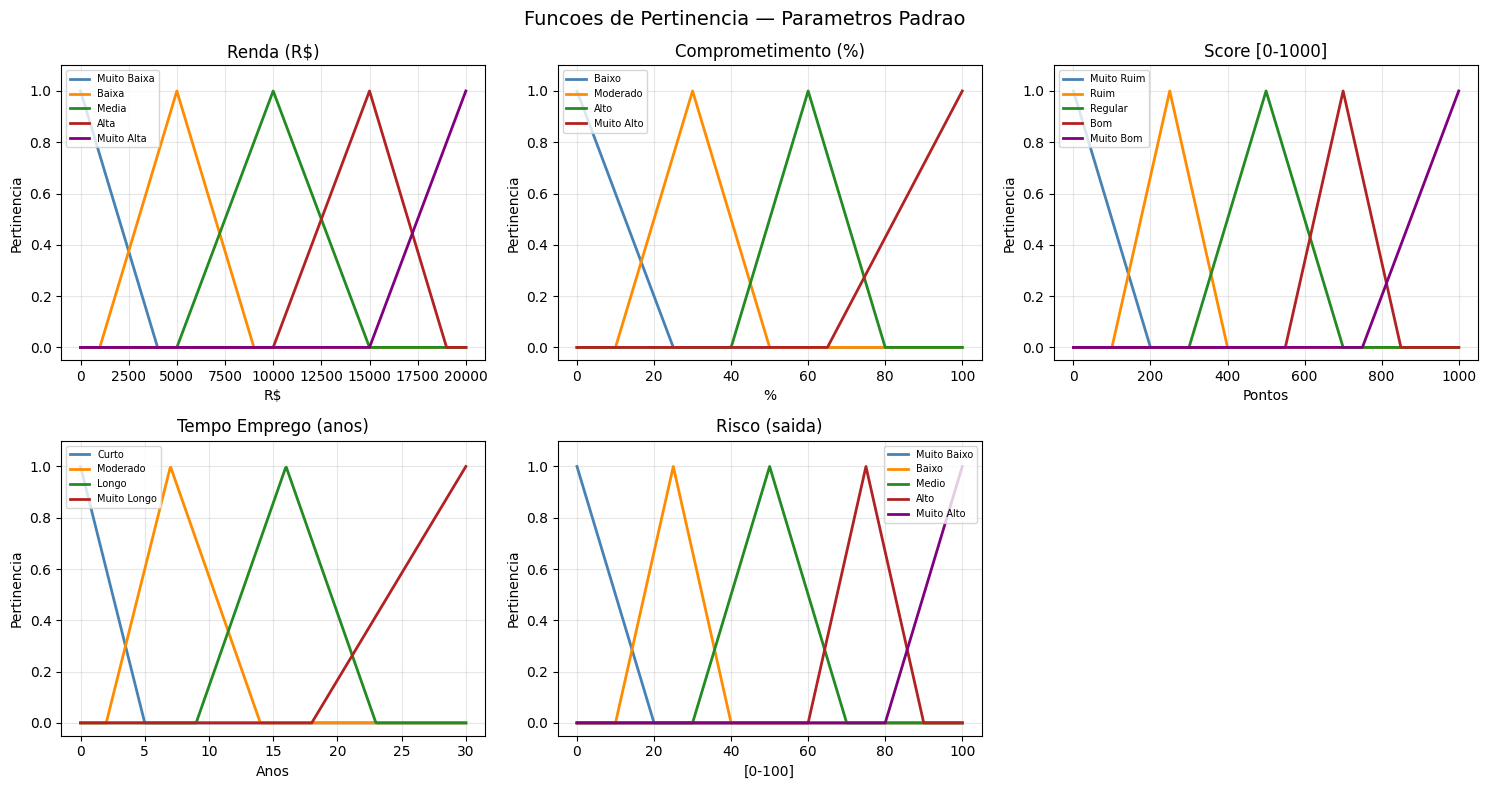

Salvo: resultados/fuzzy_antes/funcoes_pertinencia.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Funcoes de Pertinencia — Parametros Padrao", fontsize=14)

variaveis = [
    ("renda",    np.linspace(0,20000,501), "R$",
     ["muito_baixa","baixa","media","alta","muito_alta"],
     ["Muito Baixa","Baixa","Media","Alta","Muito Alta"]),
    ("comp",     np.linspace(0,100,501),   "%",
     ["baixo","moderado","alto","muito_alto"],
     ["Baixo","Moderado","Alto","Muito Alto"]),
    ("score",    np.linspace(0,1000,501),  "Pontos",
     ["muito_ruim","ruim","regular","bom","muito_bom"],
     ["Muito Ruim","Ruim","Regular","Bom","Muito Bom"]),
    ("tempo",    np.linspace(0,30,501),    "Anos",
     ["curto","moderado","longo","muito_longo"],
     ["Curto","Moderado","Longo","Muito Longo"]),
    ("risco",    np.linspace(0,100,501),   "[0-100]",
     ["muito_baixo","baixo","medio","alto","muito_alto"],
     ["Muito Baixo","Baixo","Medio","Alto","Muito Alto"]),
]
titulos = ["Renda (R$)","Comprometimento (%)","Score [0-1000]","Tempo Emprego (anos)","Risco (saida)"]
cores   = ['steelblue','darkorange','forestgreen','firebrick','purple','saddlebrown']

for k, (var, universo, xlabel, termos, rotulos) in enumerate(variaveis):
    ax = axes[k // 3][k % 3]
    for j, (t, rot) in enumerate(zip(termos, rotulos)):
        ax.plot(universo, fuzz.trimf(universo, DEFAULT_PARAMS[f"{var}_{t}"]),
                color=cores[j], lw=2, label=rot)
    ax.set_title(titulos[k])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pertinencia")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig("resultados/fuzzy_antes/funcoes_pertinencia.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: resultados/fuzzy_antes/funcoes_pertinencia.png")


In [6]:
CENARIOS = [
    (18000, 10,  920, 20,  7.0, "Excelente: renda alta, score otimo, baixo comp"),
    (  800, 85,  120,  1, 93.0, "Pessimo: renda baixa, score ruim, comp alto"),
    ( 6000, 35,  520,  5, 50.0, "Tipico: renda e score medios"),
    ( 9000, 45,  680,  8, 35.0, "Fronteiricio baixo-medio: score bom, comp mod"),
    ( 5000, 65,  410,  3, 70.0, "Fronteiricio medio-alto: score ruim, comp alto"),
    (20000, 20,  150,  2, 55.0, "Conflitante: renda alta mas score muito ruim"),
    ( 1500, 15,  720, 22, 25.0, "Conflitante: renda baixa mas score bom e tempo longo"),
    (20000,  5,  980, 30,  7.0, "Critico baixo: todos favoraveis"),
    (  500, 95,   50,  0, 93.0, "Critico alto: todos desfavoraveis"),
    ( 7000, 20,  480, 25, 28.0, "Mitigado: tempo longo compensa score regular"),
]

print(f" {'N':>2}  {'Descricao':<52} {'Esp':>5}  {'Obtido':>7}  {'Label':<13} {'Erro':>5}")
print("-" * 90)
MAE_ANTES_LISTA = []
LABELS_RISCO = [(0,15,"Muito Baixo"),(15,35,"Baixo"),(35,65,"Medio"),(65,85,"Alto"),(85,101,"Muito Alto")]
for i, (rv, cv, sv, tv, esp, desc) in enumerate(CENARIOS, 1):
    obtido = mamdani_fast(rv, cv, sv, tv, DEFAULT_PARAMS)
    erro   = abs(obtido - esp)
    MAE_ANTES_LISTA.append(erro)
    label  = next(l for lo,hi,l in LABELS_RISCO if lo <= obtido < hi)
    print(f" {i:>2}  {desc:<52} {esp:>5.1f}  {obtido:>7.1f}  {label:<13} {erro:>5.1f}")
print("-" * 90)
MAE_ANTES = float(np.mean(MAE_ANTES_LISTA))
print(f"MAE medio (parametros padrao): {MAE_ANTES:.4f}")


  N  Descricao                                              Esp   Obtido  Label          Erro
------------------------------------------------------------------------------------------
  1  Excelente: renda alta, score otimo, baixo comp         7.0      7.4  Muito Baixo     0.4
  2  Pessimo: renda baixa, score ruim, comp alto           93.0     92.5  Muito Alto      0.5
  3  Tipico: renda e score medios                          50.0     50.0  Medio           0.0
  4  Fronteiricio baixo-medio: score bom, comp mod         35.0     44.7  Medio           9.7
  5  Fronteiricio medio-alto: score ruim, comp alto        70.0     75.0  Alto            5.0
  6  Conflitante: renda alta mas score muito ruim          55.0     68.6  Alto           13.6
  7  Conflitante: renda baixa mas score bom e tempo longo  25.0     16.9  Baixo           8.1
  8  Critico baixo: todos favoraveis                        7.0      6.9  Muito Baixo     0.1
  9  Critico alto: todos desfavoraveis                     93.0

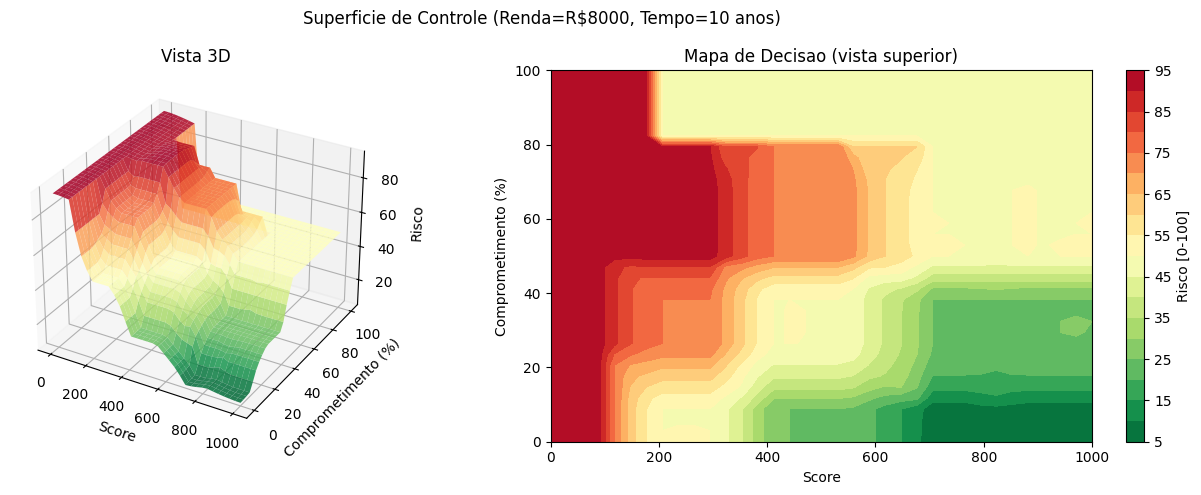

Salvo: resultados/fuzzy_antes/superficie_controle.png


In [7]:
_score_range = np.linspace(0, 1000, 35)
_comp_range  = np.linspace(0, 100,  35)
_renda_fixa  = 8000.0
_tempo_fixo  = 10.0

X, Y = np.meshgrid(_score_range, _comp_range)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = mamdani_fast(_renda_fixa, Y[i,j], X[i,j], _tempo_fixo, DEFAULT_PARAMS)

fig = plt.figure(figsize=(14, 5))
fig.suptitle(f"Superficie de Controle (Renda=R$8000, Tempo=10 anos)", fontsize=12)

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='RdYlGn_r', alpha=0.85)
ax3d.set_xlabel("Score")
ax3d.set_ylabel("Comprometimento (%)")
ax3d.set_zlabel("Risco")
ax3d.set_title("Vista 3D")

ax2d = fig.add_subplot(122)
im = ax2d.contourf(X, Y, Z, levels=20, cmap='RdYlGn_r')
ax2d.set_xlabel("Score")
ax2d.set_ylabel("Comprometimento (%)")
ax2d.set_title("Mapa de Decisao (vista superior)")
fig.colorbar(im, ax=ax2d, label="Risco [0-100]")

plt.tight_layout()
plt.savefig("resultados/fuzzy_antes/superficie_controle.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: resultados/fuzzy_antes/superficie_controle.png")


## 8. Função de Aptidão — Ponte Fuzzy ↔ PSO

**Representação de uma partícula:** vetor de 69 valores reais (23 MFs × 3 parâmetros `[a,b,c]`).

**Função objetivo (minimizar):** MAE entre saída fuzzy e valores esperados dos cenários.

O sistema fuzzy **é** a função de avaliação do PSO — isso implementa a
*Alternativa 2 (Integração Fuzzy-Evolutiva)* da Parte 2.


In [8]:
_GRUPOS_OPT = [
    ["renda_muito_baixa","renda_baixa","renda_media","renda_alta","renda_muito_alta"],
    ["comp_baixo","comp_moderado","comp_alto","comp_muito_alto"],
    ["score_muito_ruim","score_ruim","score_regular","score_bom","score_muito_bom"],
    ["tempo_curto","tempo_moderado","tempo_longo","tempo_muito_longo"],
    ["risco_muito_baixo","risco_baixo","risco_medio","risco_alto","risco_muito_alto"],
]
_KEY_IDX = {k: i for i, k in enumerate(KEYS_OPT)}

def vetor_para_params(vetor):
    """Converte vetor 1-D (69 dims) em dicionario de parametros fuzzy.
    Garante ordem semantica: pico de MF_i < pico de MF_{i+1} na mesma variavel.
    """
    params = {}
    for grupo in _GRUPOS_OPT:
        var = prefixo(grupo[0])
        lo, hi = LIMITES_VARS[var]
        delta = (hi - lo) * 0.01
        mfs = []
        for key in grupo:
            i = _KEY_IDX[key]
            vals = sorted(vetor[i*3 : i*3+3])
            a, b, c = [float(np.clip(v, lo, hi)) for v in vals]
            if a == b == c:
                c = min(c + delta, hi)
                if c == a:
                    a = max(a - delta, lo)
            a, b, c = min(a, b), b, max(b, c)
            mfs.append([a, b, c])
        mfs.sort(key=lambda x: x[1])
        for key, abc in zip(grupo, mfs):
            params[key] = abc
    return params

def fitness(vetor):
    """MAE do sistema fuzzy sobre CENARIOS (minimizar)."""
    params = vetor_para_params(vetor)
    erros  = [abs(mamdani_fast(rv,cv,sv,tv,params) - esp)
              for rv,cv,sv,tv,esp,_ in CENARIOS]
    return float(np.mean(erros))

v_padrao = np.array([v for k in KEYS_OPT for v in DEFAULT_PARAMS[k]], dtype=float)
print(f"Fitness dos parametros padrao: {fitness(v_padrao):.4f}  (deve coincidir com MAE_ANTES)")


Fitness dos parametros padrao: 5.3591  (deve coincidir com MAE_ANTES)


## 9. Algoritmo PSO

**Equações de atualização (Kennedy & Eberhart, 1995):**

```
v[t+1] = w·v[t] + c1·r1·(pbest − x[t]) + c2·r2·(gbest − x[t])
x[t+1] = clip(x[t] + v[t+1], lb, ub)
```

| Parâmetro | Valor | Descrição |
|-----------|-------|-----------|
| `n` | 40 | Número de partículas |
| `max_iter` | 150 | Iterações máximas |
| `w` | 0,7 | Inércia |
| `c1` | 1,5 | Componente cognitiva |
| `c2` | 1,5 | Componente social |
| `dim` | 69 | Dimensão do espaço (23 MFs × 3) |


In [9]:
class PSO:
    def __init__(self, n=40, dim=DIM, lb=None, ub=None,
                 w=0.7, c1=1.5, c2=1.5, max_iter=150, seed=42):
        np.random.seed(seed)
        self.n, self.dim = n, dim
        self.w, self.c1, self.c2 = w, c1, c2
        self.T = max_iter
        self.lb = np.array(lb, dtype=float)
        self.ub = np.array(ub, dtype=float)

        self.pos  = self.lb + np.random.rand(n, dim) * (self.ub - self.lb)
        self.vel  = np.zeros((n, dim))

        self.pbest_pos = self.pos.copy()
        self.pbest_fit = np.array([fitness(p) for p in self.pos])
        idx = np.argmin(self.pbest_fit)
        self.gbest_pos = self.pbest_pos[idx].copy()
        self.gbest_fit = float(self.pbest_fit[idx])
        self.historico = [self.gbest_fit]

    def run(self, verbose=True):
        for t in range(1, self.T + 1):
            r1 = np.random.rand(self.n, self.dim)
            r2 = np.random.rand(self.n, self.dim)
            self.vel = (self.w * self.vel
                        + self.c1 * r1 * (self.pbest_pos - self.pos)
                        + self.c2 * r2 * (self.gbest_pos - self.pos))
            self.pos = np.clip(self.pos + self.vel, self.lb, self.ub)
            fits = np.array([fitness(p) for p in self.pos])
            melhores = fits < self.pbest_fit
            self.pbest_pos[melhores] = self.pos[melhores]
            self.pbest_fit[melhores] = fits[melhores]
            melhor_idx = np.argmin(fits)
            if fits[melhor_idx] < self.gbest_fit:
                self.gbest_fit = float(fits[melhor_idx])
                self.gbest_pos = self.pos[melhor_idx].copy()
            self.historico.append(self.gbest_fit)
            if verbose and (t % 30 == 0 or t == 1 or t == self.T):
                print(f"  Iter {t:>3}/{self.T} | gbest={self.gbest_fit:.4f} | media={fits.mean():.4f}")
        return self.gbest_pos, self.gbest_fit

print("Classe PSO definida.")


Classe PSO definida.


In [10]:
lb_vec, ub_vec = [], []
for key in KEYS_OPT:
    lo, hi = LIMITES_VARS[prefixo(key)]
    lb_vec += [lo, lo, lo]
    ub_vec += [hi, hi, hi]

print(f"MAE antes da otimizacao (parametros padrao): {MAE_ANTES:.4f}")
print()
print("Iniciando PSO - 40 particulas, 150 iteracoes...")
t0 = time.time()

pso = PSO(n=40, dim=DIM, lb=lb_vec, ub=ub_vec,
          w=0.7, c1=1.5, c2=1.5, max_iter=150, seed=SEED_GLOBAL)
melhor_vetor, MAE_DEPOIS = pso.run(verbose=True)
PARAMS_OPT = vetor_para_params(melhor_vetor)

t1 = time.time()
print(f"\nMAE depois da otimizacao: {MAE_DEPOIS:.4f}")
print(f"Melhoria absoluta : {MAE_ANTES - MAE_DEPOIS:.4f}")
print(f"Melhoria relativa : {(MAE_ANTES - MAE_DEPOIS) / MAE_ANTES * 100:.1f}%")
print(f"Tempo de execucao : {t1-t0:.1f}s")


MAE antes da otimizacao (parametros padrao): 5.3591

Iniciando PSO - 40 particulas, 150 iteracoes...
  Iter   1/150 | gbest=14.7177 | media=21.2762


  Iter  30/150 | gbest=2.7864 | media=5.3046


  Iter  60/150 | gbest=2.0013 | media=2.6094


  Iter  90/150 | gbest=1.5646 | media=2.0247


  Iter 120/150 | gbest=1.1046 | media=1.2912


  Iter 150/150 | gbest=1.0214 | media=1.0837

MAE depois da otimizacao: 1.0214
Melhoria absoluta : 4.3377
Melhoria relativa : 80.9%
Tempo de execucao : 12.0s


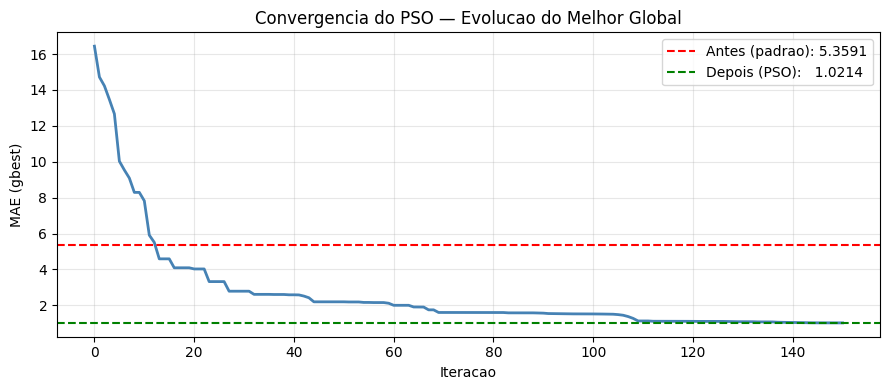

Salvo: resultados/evolucao/convergencia_pso.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pso.historico, color='steelblue', lw=2)
ax.set_xlabel("Iteracao")
ax.set_ylabel("MAE (gbest)")
ax.set_title("Convergencia do PSO — Evolucao do Melhor Global")
ax.grid(True, alpha=0.3)
ax.axhline(MAE_ANTES,  color='red',   ls='--', lw=1.5, label=f"Antes (padrao): {MAE_ANTES:.4f}")
ax.axhline(MAE_DEPOIS, color='green', ls='--', lw=1.5, label=f"Depois (PSO):   {MAE_DEPOIS:.4f}")
ax.legend()
plt.tight_layout()
plt.savefig("resultados/evolucao/convergencia_pso.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: resultados/evolucao/convergencia_pso.png")


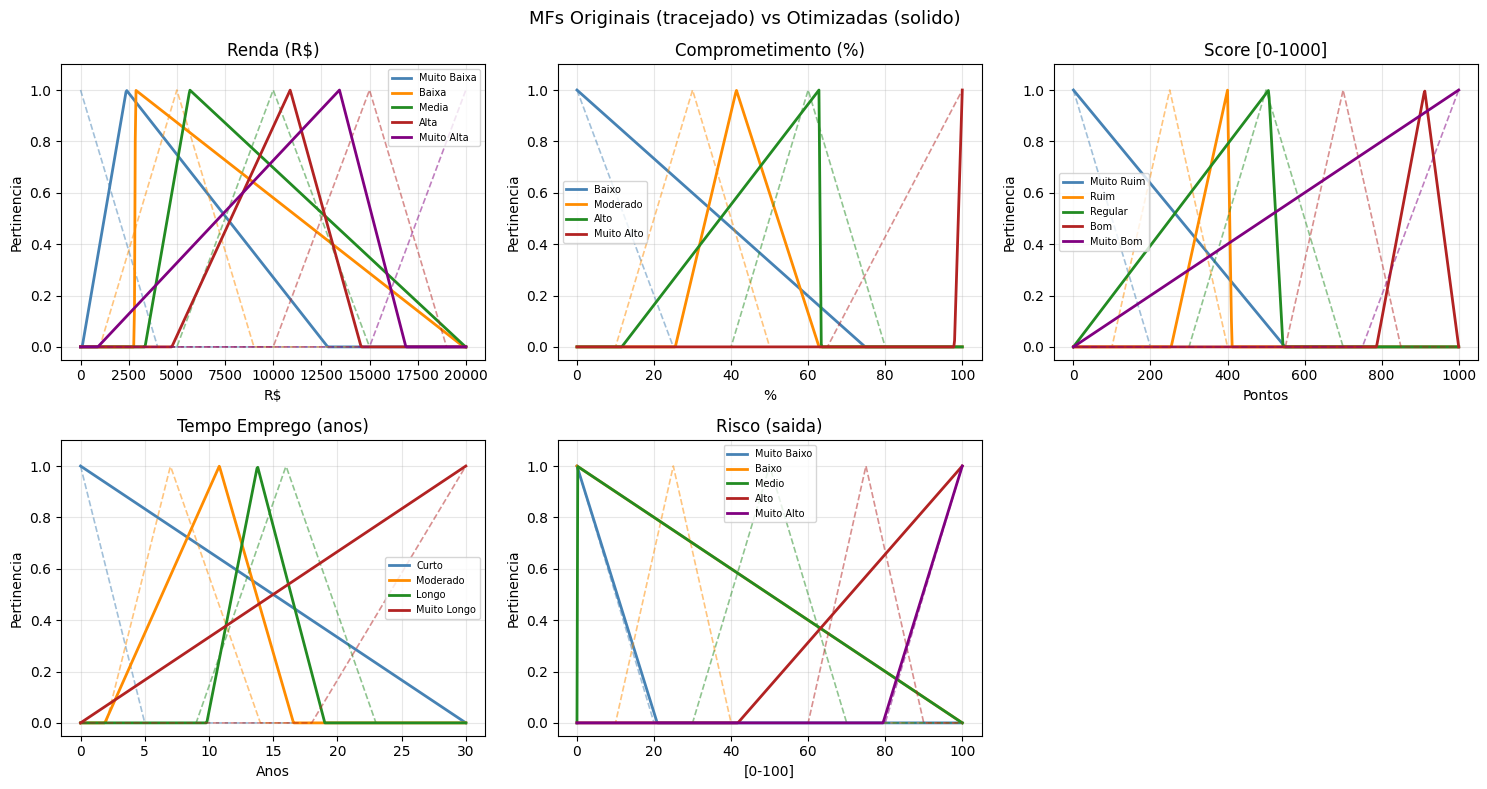

Salvo: resultados/fuzzy_depois/mfs_otimizadas.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("MFs Originais (tracejado) vs Otimizadas (solido)", fontsize=13)

variaveis = [
    ("renda",    np.linspace(0,20000,501), "R$",
     ["muito_baixa","baixa","media","alta","muito_alta"],
     ["Muito Baixa","Baixa","Media","Alta","Muito Alta"]),
    ("comp",     np.linspace(0,100,501),   "%",
     ["baixo","moderado","alto","muito_alto"],
     ["Baixo","Moderado","Alto","Muito Alto"]),
    ("score",    np.linspace(0,1000,501),  "Pontos",
     ["muito_ruim","ruim","regular","bom","muito_bom"],
     ["Muito Ruim","Ruim","Regular","Bom","Muito Bom"]),
    ("tempo",    np.linspace(0,30,501),    "Anos",
     ["curto","moderado","longo","muito_longo"],
     ["Curto","Moderado","Longo","Muito Longo"]),
    ("risco",    np.linspace(0,100,501),   "[0-100]",
     ["muito_baixo","baixo","medio","alto","muito_alto"],
     ["Muito Baixo","Baixo","Medio","Alto","Muito Alto"]),
]
titulos = ["Renda (R$)","Comprometimento (%)","Score [0-1000]","Tempo Emprego (anos)","Risco (saida)"]
cores   = ['steelblue','darkorange','forestgreen','firebrick','purple','saddlebrown']

for k, (var, universo, xlabel, termos, rotulos) in enumerate(variaveis):
    ax = axes[k // 3][k % 3]
    for j, (t, rot) in enumerate(zip(termos, rotulos)):
        abc_pad = DEFAULT_PARAMS[f"{var}_{t}"]
        abc_opt = PARAMS_OPT[f"{var}_{t}"]
        ax.plot(universo, fuzz.trimf(universo, abc_pad), color=cores[j], ls='--', lw=1.2, alpha=0.5)
        ax.plot(universo, fuzz.trimf(universo, abc_opt), color=cores[j], ls='-',  lw=2,   label=rot)
    ax.set_title(titulos[k])
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pertinencia")
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig("resultados/fuzzy_depois/mfs_otimizadas.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: resultados/fuzzy_depois/mfs_otimizadas.png")


In [13]:
print(f" {'N':>2}  {'Descricao':<50} {'Esp':>5}  {'Antes':>6}  {'Depois':>7}  {'EA':>5}  {'ED':>5}  {'Mel':>6}")
print("-" * 94)
rows_csv = []
for i, (rv,cv,sv,tv,esp,desc) in enumerate(CENARIOS, 1):
    antes  = mamdani_fast(rv, cv, sv, tv, DEFAULT_PARAMS)
    depois = mamdani_fast(rv, cv, sv, tv, PARAMS_OPT)
    ea, ed = abs(antes-esp), abs(depois-esp)
    print(f" {i:>2}  {desc:<50} {esp:>5.1f}  {antes:>6.1f}  {depois:>7.1f}  {ea:>5.1f}  {ed:>5.1f}  {ea-ed:>+6.1f}")
    rows_csv.append({"cenario":i,"descricao":desc,"esperado":esp,"antes":round(antes,2),
                     "depois":round(depois,2),"ea":round(ea,2),"ed":round(ed,2)})
print("-" * 94)
_mae_a = np.mean([r['ea'] for r in rows_csv])
_mae_d = np.mean([r['ed'] for r in rows_csv])
print(f"    {'MAE MEDIO':<54} {'':>5}  {_mae_a:>6.2f}  {_mae_d:>7.2f}")
print(f"    {'DESVIO PADRAO':<54} {'':>5}  {np.std([r['ea'] for r in rows_csv]):>6.2f}  {np.std([r['ed'] for r in rows_csv]):>7.2f}")

import csv
with open("resultados/comparacao_cenarios.csv","w",newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows_csv[0].keys()))
    w.writeheader(); w.writerows(rows_csv)
print("\nTabela salva em resultados/comparacao_cenarios.csv")


  N  Descricao                                            Esp   Antes   Depois     EA     ED     Mel
----------------------------------------------------------------------------------------------
  1  Excelente: renda alta, score otimo, baixo comp       7.0     7.4      7.0    0.4    0.0    +0.4
  2  Pessimo: renda baixa, score ruim, comp alto         93.0    92.5     92.9    0.5    0.1    +0.4
  3  Tipico: renda e score medios                        50.0    50.0     50.0    0.0    0.0    -0.0
  4  Fronteiricio baixo-medio: score bom, comp mod       35.0    44.7     35.9    9.7    0.9    +8.8
  5  Fronteiricio medio-alto: score ruim, comp alto      70.0    75.0     70.0    5.0    0.0    +5.0
  6  Conflitante: renda alta mas score muito ruim        55.0    68.6     55.0   13.6    0.0   +13.6
  7  Conflitante: renda baixa mas score bom e tempo longo  25.0    16.9     25.0    8.1    0.0    +8.1
  8  Critico baixo: todos favoraveis                      7.0     6.9      7.0    0.1    0.0   

Run Semente  MAE_final  Melhoria%  Tempo_s
------------------------------------------


  1       0     0.0305      99.4%     9.8s


  2       7     0.9878      81.6%    10.7s


  3      13     0.6042      88.7%    12.1s


  4      21     0.0503      99.1%     8.3s


  5      42     1.0214      80.9%    12.0s
------------------------------------------
     Media     0.5388      89.9%
    Desvio     0.4326
    Melhor     0.0305
      Pior       1.0214


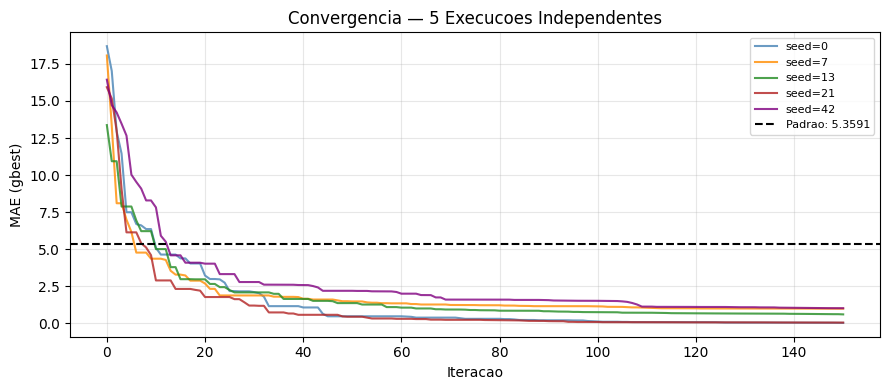

Salvo: resultados/evolucao/convergencia_5runs.png


In [14]:
sementes  = [0, 7, 13, 21, 42]
cores_run = ['steelblue','darkorange','forestgreen','firebrick','purple']
runs      = []
historicos = []

print(f"{'Run':>3} {'Semente':>7} {'MAE_final':>10} {'Melhoria%':>10} {'Tempo_s':>8}")
print("-" * 42)

for run, seed in enumerate(sementes, 1):
    t0    = time.time()
    pso_r = PSO(n=40, dim=DIM, lb=lb_vec, ub=ub_vec,
                w=0.7, c1=1.5, c2=1.5, max_iter=150, seed=seed)
    _, mae_r = pso_r.run(verbose=False)
    dt       = time.time() - t0
    melhoria = (MAE_ANTES - mae_r) / MAE_ANTES * 100
    runs.append({"run":run,"seed":seed,"mae":mae_r,"melhoria":melhoria,"tempo":dt})
    historicos.append(pso_r.historico)
    print(f"{run:>3} {seed:>7} {mae_r:>10.4f} {melhoria:>9.1f}% {dt:>7.1f}s")

print("-" * 42)
_maes      = [r['mae']      for r in runs]
_melhorias = [r['melhoria'] for r in runs]
print(f"{'Media':>10} {np.mean(_maes):>10.4f} {np.mean(_melhorias):>9.1f}%")
print(f"{'Desvio':>10} {np.std(_maes):>10.4f}")
print(f"{'Melhor':>10} {min(_maes):>10.4f}")
print(f"{'Pior':>10}   {max(_maes):>10.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
for hist, seed, cor in zip(historicos, sementes, cores_run):
    ax.plot(hist, color=cor, lw=1.5, alpha=0.8, label=f"seed={seed}")
ax.axhline(MAE_ANTES, color='black', ls='--', lw=1.5, label=f"Padrao: {MAE_ANTES:.4f}")
ax.set_xlabel("Iteracao")
ax.set_ylabel("MAE (gbest)")
ax.set_title("Convergencia — 5 Execucoes Independentes")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("resultados/evolucao/convergencia_5runs.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: resultados/evolucao/convergencia_5runs.png")


In [15]:
with open("resultados/fuzzy_depois/params_otimizados.json", "w") as f:
    json.dump(PARAMS_OPT, f, indent=2)
print("Parametros otimizados salvos em resultados/fuzzy_depois/params_otimizados.json")

print()
print("=" * 52)
print("RESUMO FINAL")
print("=" * 52)
print(f"MAE antes (parametros padrao) : {MAE_ANTES:.4f}")
print(f"MAE depois (PSO otimizado)    : {MAE_DEPOIS:.4f}")
print(f"Melhoria absoluta             : {MAE_ANTES - MAE_DEPOIS:.4f}")
print(f"Melhoria relativa             : {(MAE_ANTES - MAE_DEPOIS) / MAE_ANTES * 100:.1f}%")
print(f"N particulas / iteracoes      : 40 / 150")
print(f"Dimensao do espaco de busca   : {DIM}")
print(f"Cenarios de teste             : {len(CENARIOS)}")
print(f"Regras fuzzy                  : 18")
print("=" * 52)


Parametros otimizados salvos em resultados/fuzzy_depois/params_otimizados.json

RESUMO FINAL
MAE antes (parametros padrao) : 5.3591
MAE depois (PSO otimizado)    : 1.0214
Melhoria absoluta             : 4.3377
Melhoria relativa             : 80.9%
N particulas / iteracoes      : 40 / 150
Dimensao do espaco de busca   : 69
Cenarios de teste             : 10
Regras fuzzy                  : 18


## 16. Análise Crítica

### Adequação do sistema fuzzy ao problema

A lógica fuzzy Mamdani é adequada para avaliação de crédito porque variáveis como
"renda alta" ou "score bom" são intrinsecamente vagas. O sistema produz um índice
contínuo [0–100], mais informativo que uma classificação binária.

### Papel do PSO

O PSO otimiza os 69 parâmetros das 23 funções de pertinência triangulares usando
10 cenários de referência. A restrição de ordem semântica em `vetor_para_params`
garante que "muito_baixa" sempre tenha pico menor que "muito_alta" para qualquer
variável — evitando soluções semanticamente invertidas.

### Limitações

- **Cenários manuais:** os 10 cenários de teste foram definidos por raciocínio do
  desenvolvedor, não por dados históricos reais. Um sistema em produção exigiria
  validação com especialistas de crédito e dados empíricos.
- **Dimensionalidade:** com 4 entradas cada uma com 4–5 termos, o espaço teórico
  de regras é 5×4×5×4 = 400. As 18 regras cobrem os casos mais importantes.


In [16]:
print("Arquivos gerados em resultados/:")
for raiz, dirs, arquivos in os.walk("resultados"):
    for arq in sorted(arquivos):
        caminho = os.path.join(raiz, arq)
        tamanho = os.path.getsize(caminho)
        print(f"  {caminho:<55} {tamanho/1024:>6.1f} KB")


Arquivos gerados em results/:
  results\comparacao_cenarios.csv                            0.8 KB
  results\validacao_dataset_completo.csv                    37.1 KB
  results\evolution\convergencia_5runs.png                  69.7 KB
  results\evolution\convergencia_pso.png                    47.3 KB
  results\fuzzy_after\mfs_otimizadas.png                   411.1 KB
  results\fuzzy_after\params_otimizados.json                 1.9 KB
  results\fuzzy_before\funcoes_pertinencia.png             272.3 KB
  results\fuzzy_before\superficie_controle.png             246.5 KB
